# Introductie

Het doel van dit experiment is de bepaling van het volume van een ballon. Dit wordt gedaan door water en de ballon op te warmen. Het verschil in volume voor elke temperatuur wordt gemeten en vastgelegd

Volgens [de ideale gaswet](https://nl.wikipedia.org/wiki/Algemene_gaswet) wordt het volume $V$ van een (ideaal) gas gegeven door: 

$$
    V = n R T / P
$$

waarin 

- $n$ het aantal mol gas,
- $R$ de ideale gasconstante,
- $T$ de absolute temperatuur,
- $P$ de druk.

In dit practicum veranderen we de temperatuur en meten we de verandering van het volume van het gas. De proef is met name kwalitatief van aard en laat zien hoe lastig het is een extensieve grootheid als volume te meten.

## Theorie

De wet van Charles relateerd volume aan temperatuur $$V \propto T$$
Wanneer we een ballon onder water dompelen en het water opwarmen, krijgen we deze vergelijking:

$$V_{ballon}(T) = V_{totaal}(T) - V_{water}(T)$$
 
Om de experimentele data te gebruiken moeten we de hellingen van de verschillen tussen de volumes weten: 

$$\text{Slope}_1 = \frac{\Delta V_{total}}{\Delta T}$$

$$\text{Slope}_2 = \frac{\Delta V_{water}}{\Delta T}$$

Isoleren voor de helling van de ballon geeft: 

$$\text{Slope}_{ballon} = \text{Slope}_1 - \text{Slope}_2$$

De helling van de ballon kan tegen Charles' wet worden vergeleken om het volume van de ballon te verkrijgen:

$$\text{Slope}_{ballon} = V_0 / T_0$$

Waarbij $V_0$ het beginvolume van de ballon is en $T_0$ de begintemperatuur.


# Methode en materialen

## Ontwerp

Om het volume van een hoeveelheid gas bij constante druk te meten is niet zo eenvoudig. Je kunt het gas vrij eenvoudig in een ballon stoppen en dan schatten hoe de diameter van de ballon verandert als functie van de temperatuur, maar dat geeft een relatief grote fout (waarom?). We maken daarom gebruik van de wet van [Archimedes](https://nl.wikipedia.org/wiki/Wet_van_Archimedes). 

## Materialen

- eenvoudige feestballon
- bekerglas
- tweede bekerglas om mee bij te vullen
- thermometer
- verhittingsplaat
- deksel met vulcilinder met maatstrepen (met iets kleinere diameter dan interne diameter maatbeker)
- (per 5 groepjes) een $10 \mathrm{ml}$ maatcilinder

## Procedure

- Blaas de ballon op, maar niet verder dan $5 \mathrm{cm}$ in diameter. Deze moet makkelijk in de maatbeker passen. 
- Knoop de ballon goed dicht zodat er geen lucht kan ontsnappen. 
- Dompel de ballon onder in de maatbeker met water met behulp van het deksel.
- Pas het waterniveau aan zodat de meniscus (de bovenkant van het water) bij een van de onderste maatstrepen van de vulcilinder van het deksel zit. 
- Let op dat er luchtbellen kunnen plakken aan de ballon wat leidt tot een systematische fout. Verifieer dat je zo min mogelijk systematische fouten maakt en meet op welke maatstreep de meniscus zich bevindt.
- Verhoog stapsgewijst de temperatuur van het water (en dus de ballon). *Let op dat je de temperatuur maximaal een graad of 20 kan verhogen, want als je voorbij de vulcilinder komt met de meniscus, dan kan je de volumeverandering niet meer nauwkeurig bepalen.*
- Laat het geheel na elke temperatuurtoename een minuut 'rusten' om zo de tijd te geven om in thermisch evenwicht te komen.
- Meet na elke temperatuurtoename de temperatuur en de positie van de meniscus.

Het verschiloppervlak tussen de binnendiameter van de maatbeker en de buitendiameter van de vulcilinder is $10.0 \mathrm{cm}^{2}$. Je kunt die handmatig kalibreren met behulp van de kleine maatcilinder die in het lokaal aanwezig is. De maatstreepjes die op de vulcilinder zijn gekerfd zitten op een onderlinge afstand van $1.0 \mathrm{mm}$.

```{exercise} Analyseer de data
Plot de volumeverandering van de ballon als functie van de temperatuur. Zie je hier een lineair verband? Bepaal dan ook wat het startvolume van de ballon was door te extrapoleren naar een absolute temperatuur van $0 \mathrm{K}$.
```

Als je kritisch nadenkt over deze grafiek en de extrapolatie, dan kun je bezwaar maken tegen de precisie van deze proef. Het water in de maatbeker zet ook uit onder de verhoging van de temperatuur en geeft een systematische fout. Daar kun je een correctie voor uitvoeren. Voer die correctie uit als je nog genoeg tijd hebt:

```{exercise} Verbeterde meting
- Maak de maatbeker leeg en vul deze opnieuw met water tot een van de onderste maatstrepen van de vulcilinder (dus zonder ballon). 
- Verhit de maatbeker weer stapsgewijs en meet na elke stap de temperatuur en de hoogte van de meniscus.

Kun je nu met behulp van deze tweede meting een betere afschatting geven voor het startvolume van de ballon? 
```

## Meetgegevens en Onzekerheden

In [1]:
#Inladen libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Meetgegevens en constanten

temps = [18.8,21.5,27.5,32.8,37.4,40.7,44.7,50.4,54.3] #celcius
hoogtes = [0.1,0.3,0.5,0.7,1.1,1.3,1.5,1.8,2.0] #cm
watertemps = [18,26,37.2,46.7,61.5] #celcius
waterhoogtes = ([0,0.1,0.2,0.3,0.5]) #cm

vwater_begin = 180 #mL
diam_beker = 7.66 # cm
diam_deksel = 6.77 # cm

In [2]:
#Onzekerheden
sigma_thermometer = 0.1 # thermometer onzekerheid (celcius)
sigma_waterhoogtes = 0.02 # cm

# Resultaten

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Berekeningen
opp_water = 1/4 * np.pi * (diam_beker**2 - diam_deksel**2) #cm2
volumes = (np.asarray(hoogtes) - hoogtes[0]) * opp_water + vwater_begin
temps_abs = np.asarray(temps) + 273
coef = np.polyfit(temps_abs, volumes, 1)
func = np.poly1d(coef)

#Volumes
watervolumes = (np.asarray(waterhoogtes) - waterhoogtes[0]) * opp_water + 200
watertemps_abs = np.asarray(watertemps) + 273
watercoef = np.polyfit(watertemps_abs, watervolumes, 1)
waterfunc = np.poly1d(watercoef)
coef, cov_tot = np.polyfit(temps_abs, volumes, 1, cov=True)

#Coefficients and calculation of the volume of the balloon.
print(coef,watercoef)
m_air=coef[0]-watercoef[0]
vballon=volumes[0]-m_air*temps_abs[0]
print(vballon)

[ 0.54528084 20.67400409] [1.12969519e-01 1.67099095e+02]
53.85155510725335


<Figure size 640x480 with 0 Axes>

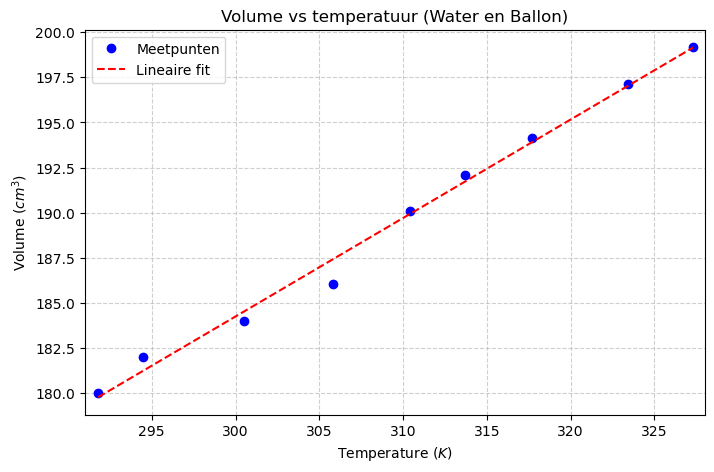

<Figure size 640x480 with 0 Axes>

In [5]:
#Figuur 1: Volume vs temperatuur (Water en Ballon)

plt.figure(figsize=(8, 5))
plt.title("Volume vs temperatuur (Water en Ballon)")
plt.plot(temps_abs, volumes, 'ob', label='Meetpunten')
plt.plot(temps_abs, func(temps_abs), '--r', label='Lineaire fit')
plt.xlabel('Temperature ($K$)')
plt.xlim(291,328)
plt.ylabel('Volume ($cm^3$)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.figure()

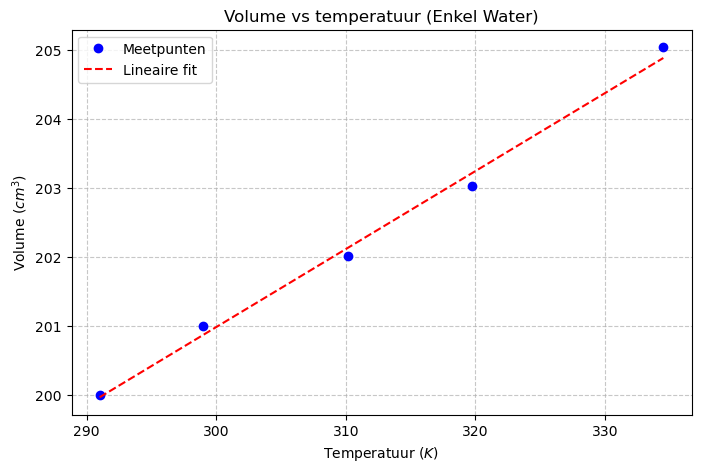

In [6]:
plt.figure(figsize=(8, 5))
plt.title("Volume vs temperatuur (Enkel Water)")
plt.plot(watertemps_abs, watervolumes, 'ob', label='Meetpunten')
plt.plot(watertemps_abs, waterfunc(watertemps_abs), '--r', label='Lineaire fit')
plt.xlabel('Temperatuur ($K$)')
plt.ylabel('Volume ($cm^3$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## Onzekerheid

De onzekerheid in het volume van de ballon kan worden berekend als volgt: 

$$\sigma_{V_b} = \sqrt{ \underbrace{(T \cdot \sigma_{m_{tot}})^2 + (T \cdot \sigma_{m_w})^2}_{\text{Onzekerheid in de helling}} + \underbrace{((m_{tot} - m_w) \cdot \sigma_T)^2}_{\text{Error in thermometer}} + \underbrace{\sigma_{V_{Aflezing, tot}}^2 + \sigma_{V_{Aflezing, w}}^2}_{\text{Maatbeker aflezen}} }$$

Waarbij de onzekerheid in $V$ door de aflezingsfout in $h$ luidt als:

$$\sigma_V = \sqrt{\left( \frac{\partial V}{\partial h} \cdot \sigma_h \right)^2} = A_{opp} \cdot \sigma_h$$

In [7]:
#Eerst de onzekerheden in de hellingen van de volume expansies vinden:

coef, cov_tot = np.polyfit(temps_abs, volumes, 1, cov=True)
watercoef, cov_w = np.polyfit(watertemps_abs, watervolumes, 1, cov=True)

#Apart de termen berekenen:
sigma_m_tot = np.sqrt(cov_tot[0,0])  # Error in helling met ballon en water
sigma_m_w   = np.sqrt(cov_w[0,0])    # Error in helling met enkel het water
sigma_V_read = opp_water * sigma_waterhoogtes
onz_helling = (temps_abs * sigma_m_tot)**2 + (temps_abs * sigma_m_w)**2
onz_temp    = (m_air * sigma_thermometer)**2
onz_maatb   = sigma_V_read**2 + sigma_V_read**2 

#Alle termen optellen:
sigma_V_b = np.mean(np.sqrt((onz_helling + onz_temp + onz_maatb)))



In [8]:
#Waardes printen:

print(f"Het berekende volume van de ballon is: {vballon:.2f} cm³")
print(f"De onzekerheid is: {sigma_V_b:.2f} cm³")



Het berekende volume van de ballon is: 53.85 cm³
De onzekerheid is: 5.97 cm³


# Discussie en conclusie




Het doel van dit experiment was de bepaling van het volume van een ballon. Dit werd gedaan door water en een ballon in een maatbeker te plaatsen, waarna het volumeverschil werd bepaald. Het berekende volume van de ballon was: 53.85 cm³, met een onzekerheid van 5.97 cm³ Onze meting laat zien dat het volume van een gas bij constante druk lineair toeneemt met de absolute temperatuur, in overeenstemming met de ideale gaswet. De extrapolatie naar $0 \mathrm{K}$ geeft een redelijke schatting van het startvolume van de ballon, hoewel de precisie beperkt is. Onze meting van het water op zichzelf liet zien dat de toename in volume heel klein is, en dus een kleine systematische fout oplevert. Na correctie voor deze systematische fout kregen we een iets betere schatting van het startvolume van de ballon.